In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# import phase_mixing_utils
# import PhaseRetrieval
from skimage import color
from skimage.transform import rescale
from scipy.ndimage.filters import gaussian_filter
from skimage import io
from skimage.registration import phase_cross_correlation as register_translation
from simulate_zp import cal_zp
# from simulate_zp_bs import cal_zp_bs, cal_zp_bs_NA
# from tqdm import tqdm
from skimage import io
from probe_prop import propagate
from scipy.ndimage import binary_fill_holes


def _HIOupdate_contrast2(T_old, T_prime, S, beta=0.7):
    """
    Standard HIO update on a complex object/field.

    T_old   : previous estimate (complex)
    T_prime : projected estimate after Fourier-modulus projection (complex)
    S       : support mask (True inside support)
    beta    : HIO relaxation parameter
    """
    S = S.astype(bool)
    T_next = T_prime.copy()
    T_next[S] = T_prime[S]
    T_next[~S] = T_old[~S] - beta * T_prime[~S]
    # T_next[~S] = 0
    return T_next

def HIO_T_ERoutside(T_old, T_prime, S, beta=0.7):
    # support 内 HIO/ER都可；这里保留 T_prime
    T_next = T_old.copy()
    T_next[S]  = T_prime[S]
    T_next[~S] = 0.0 + 0.0j   # 关键：背景对 T 只约束复数值=0，不管相位
    return T_next

def fftc(x):
    N = np.prod(x.shape)
    return np.fft.fftshift(np.fft.fftn(np.fft.ifftshift(x))) / np.sqrt(N)

def ifftc(X):
    N = np.prod(X.shape)
    return np.fft.fftshift(np.fft.ifftn(np.fft.ifftshift(X))) * np.sqrt(N)

def threshold_object(O, amp_min=0.7, amp_max=1.2, pha_min=-0.1, pha_max=0.1):
    amp_O = np.abs(O)
    pha_O = np.angle(O)
    
    amp_O[amp_O > amp_max] = amp_max
    amp_O[amp_O < amp_min] = amp_min
    pha_O[pha_O > pha_max] = pha_max
    pha_O[pha_O < pha_min] = pha_min
    
    O_thresholded = amp_O * np.exp(1j * pha_O)
    return O_thresholded


Text(0.5, 1.0, 'zp at detector plane')

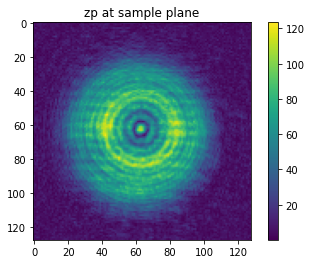

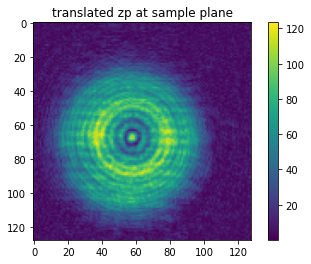

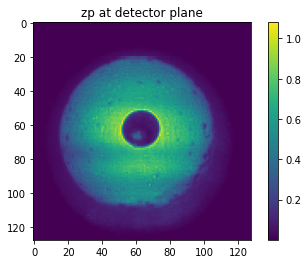

In [71]:


# probe = np.load('S315459/0/recon_data/recon_315459_0_probe_ave.npy')
# probe_defocus = np.load('/Users/xiaoyinzheng/Library/CloudStorage/GoogleDrive-xiaoyin.zheng@stonybrook.edu/Other computers/Windows PC/Research_Data (2)/CDI/CDI_realdata/S351145/t1/recon_data/recon_351145_t1_probe.npy')
probe_defocus = np.load(r'/Users/xiaoyinzheng/Library/CloudStorage/GoogleDrive-xiaoyin.zheng@stonybrook.edu/Other computers/Windows PC/Research_Data (2)/CDI/CDI_realdata/S351145/tt_1m_n/recon_data/recon_351145_tt_1m_n_probe.npy')

probe_defocus = probe_defocus[0] * np.sqrt(20)
# probe_defocus = probe_defocus / np.max(np.abs(probe_defocus))
# probe = np.abs(probe)
# probe_defocus = propagate(probe, 12, 637, 24*1e-3, 24*1e-3)


plt.figure()
plt.imshow(np.abs(probe_defocus))
plt.title('zp at sample plane')
plt.colorbar()

probe_defocus_translated = np.roll(probe_defocus, shift=(5, -5), axis=(0, 1))

plt.figure()
plt.imshow(np.abs(probe_defocus_translated))
plt.title('translated zp at sample plane')
plt.colorbar()

ft_probe = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(probe_defocus))) / np.prod(probe_defocus.shape)
plt.figure()
plt.imshow(np.abs(ft_probe))
plt.colorbar()
plt.title('zp at detector plane')




## Generate the obj with the central ptychogrpahy data

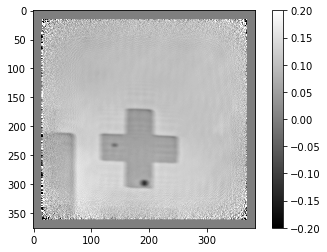

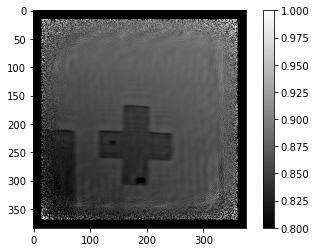

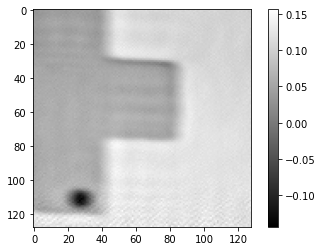

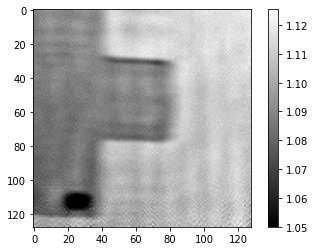

In [ ]:
%matplotlib inline
# %matplotlib qt
pha = io.imread(r'/Users/xiaoyinzheng/Library/CloudStorage/GoogleDrive-xiaoyin.zheng@stonybrook.edu/Other computers/Windows PC/Research_Data (2)/CDI/CDI_realdata/S351145/tt_1m_n/recon_tif/recon_351145_tt_1m_n_object_pha0.tif')
# pha = io.imread(r'/Users/xiaoyinzheng/Library/CloudStorage/GoogleDrive-xiaoyin.zheng@stonybrook.edu/Other computers/Windows PC/Research_Data (2)/CDI/CDI_realdata/351148/S351148/t2/recon_tif/recon_351148_t2_object_pha0.tif')
amp = io.imread(r'/Users/xiaoyinzheng/Library/CloudStorage/GoogleDrive-xiaoyin.zheng@stonybrook.edu/Other computers/Windows PC/Research_Data (2)/CDI/CDI_realdata/S351145/tt_1m_n/recon_tif/recon_351145_tt_1m_n_object_amp0.tif')

plt.figure()
# plt.imshow(pha, cmap='gray')
plt.imshow(pha, cmap='gray', vmin=-0.2, vmax=0.2)
plt.colorbar()
plt.figure()
plt.imshow(amp, cmap='gray')
plt.colorbar()

# shift_x = -40
# shift_y = 10
# cy, cx = pha.shape[0]//2 - shift_y, pha.shape[1]//2 - shift_x

cx, cy = 228, 251

pha = pha[cy-64:cy+64, cx-64:cx+64]

# amp = amp * np.sqrt(20)
# amp = amp[cy-64:cy+64, cx-64:cx+64] + 0.25
amp = amp[cy-64:cy+64, cx-64:cx+64]
amp += 0.25


plt.figure()
plt.imshow(pha, cmap='gray')
plt.colorbar()
plt.figure()
plt.imshow(amp, cmap='gray')
plt.colorbar()


obj_real = amp * np.exp(1j * pha)

## Use the obj to simualte the diffraction pattern

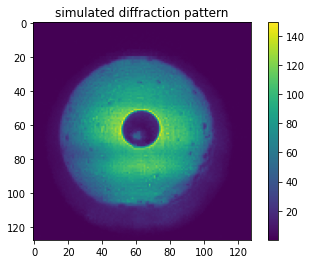

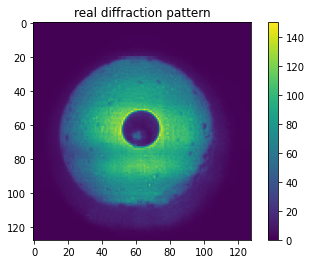

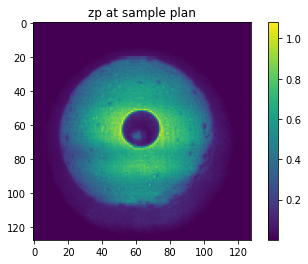

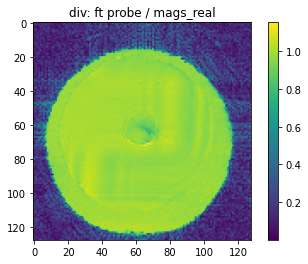

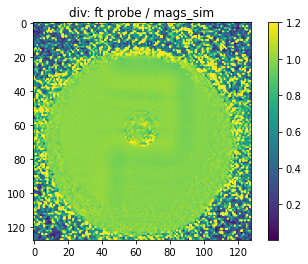

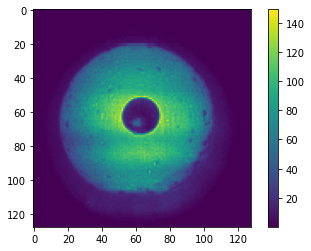

In [86]:
# obj, probe_defocus
%matplotlib inline
F_OP = np.fft.fftn(obj_real * probe_defocus) / np.sqrt(np.prod(obj_real.shape))
mags_sim = np.abs(F_OP)
mags_sim = np.fft.fftshift(mags_sim)
plt.figure()
plt.imshow(mags_sim)
plt.title('simulated diffraction pattern')
# plt.imshow(mags_sim)
plt.colorbar()

# read the real diffraction pattern
# mags_real = io.imread('/Users/xiaoyinzheng/Library/CloudStorage/GoogleDrive-xiaoyin.zheng@stonybrook.edu/Other computers/Windows PC/Research_Data (2)/CDI/CDI_realdata/eiger2_image_351147_slice0.tiff')
mags_real = io.imread(r'/Users/xiaoyinzheng/Library/CloudStorage/GoogleDrive-xiaoyin.zheng@stonybrook.edu/Other computers/Windows PC/Research_Data (2)/CDI/CDI_realdata/eiger2_image_351147.tiff')
# mags_real = mags_real[0]
mags_real = np.mean(mags_real, axis=0)  # average over slices
s0 = 11
s1 = 6#8
mags_real = mags_real[np.shape(mags_real)[0]//2 - 64 - s0 : np.shape(mags_real)[0]//2 + 64 - s0, np.shape(mags_real)[1]//2 - 64 - s1 : np.shape(mags_real)[1]//2 + 64 - s1]
mags_real = np.fliplr(mags_real.T)
mags_real = np.sqrt(mags_real) #/ np.sqrt(np.prod(np.array(mags_real.shape)))
# mags_real /= np.sqrt(20)
plt.figure()
plt.imshow(mags_real, vmin=0, vmax=150)
plt.title('real diffraction pattern')
plt.colorbar()


plt.figure()
plt.imshow(np.abs(ft_probe))
plt.colorbar()
plt.title('zp at sample plan')

# %matplotlib qt
plt.figure()
plt.imshow((np.abs(ft_probe)/np.max(np.abs(ft_probe))) / (mags_real/np.max(np.abs(mags_real))))
# plt.imshow((mags_real/np.max(np.abs(mags_real))) / (np.abs(ft_probe)/np.max(np.abs(ft_probe))), vmax=1.2)

plt.colorbar()
plt.title('div: ft probe / mags_real')

# plt.figure()
# # plt.imshow(np.abs(ft_probe)/np.max(np.abs(ft_probe)) - mags_real/np.max(mags_real))
# plt.imshow((np.abs(mags_sim)/np.max(np.abs(mags_sim))) / (mags_real/np.max(np.abs(mags_real))))
# plt.colorbar()
# plt.title('diff: mags_sim & mags_real')

plt.figure()
plt.imshow((np.abs(ft_probe)/np.max(np.abs(ft_probe))) / (mags_sim/np.max(np.abs(mags_sim))), vmax=1.2)
# plt.imshow((mags_sim/np.max(np.abs(mags_sim))) / (np.abs(ft_probe)/np.max(np.abs(ft_probe))), vmax=1.2)
plt.colorbar()
plt.title('div: ft probe / mags_sim')

F_OP = np.fft.fftn(obj_real * probe_defocus) / np.sqrt(np.prod(obj_real.shape))
F_OP = np.fft.fftshift(F_OP)
plt.figure()
plt.imshow(np.abs(F_OP))
plt.colorbar()



# Mask generation

Text(0.5, 1.0, 'initial phase')

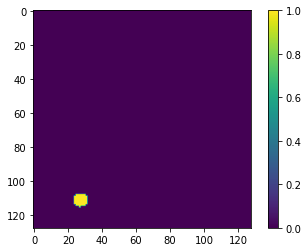

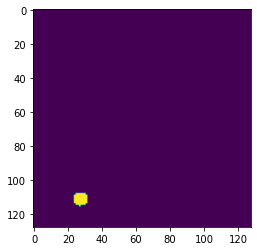

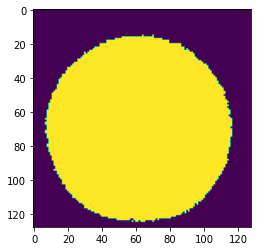

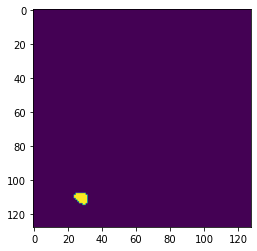

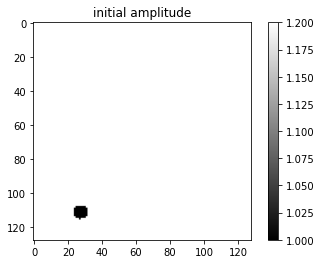

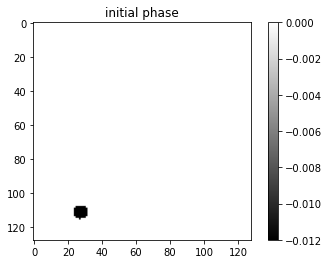

In [92]:
%matplotlib inline
from scipy import ndimage
from skimage.morphology import remove_small_objects

Smask = pha < -0.06
# Smask = ndimage.binary_dilation(Smask, iterations=10)
# Smask = remove_small_objects(Smask, min_size=1000)
plt.figure()
plt.imshow(Smask)
plt.colorbar()

Pmask = (np.abs(ft_probe)/np.max(np.abs(ft_probe))) / (mags_real/np.max(np.abs(mags_real)))
Pmask = Pmask > 0.8
Pmask = binary_fill_holes(Pmask)
combined_mask = Smask & Pmask
plt.figure()
plt.imshow(Smask)

plt.figure()
plt.imshow(Pmask)

plt.figure()
plt.imshow(combined_mask)

pha_ini = np.ones_like(Smask, dtype=float)
pha_ini[~Smask] = 0
pha_ini[Smask] = -0.012

amp_ini = np.ones_like(Smask, dtype=float)
amp_ini[~Smask] = 1.2 #0.865
amp_ini[Smask] = 1.0 #0.82

ini = amp_ini * np.exp(1j * pha_ini)
plt.figure()
plt.imshow(np.abs(ini), cmap='gray')
plt.colorbar()
plt.title('initial amplitude')

plt.figure()
plt.imshow(np.angle(ini), cmap='gray')
plt.colorbar()
plt.title('initial phase')


In [75]:
# %matplotlib inline

# amp_ini = np.ones_like(mask, dtype=float)
# amp_ini[mask] = 0.5

# plt.imshow(amp_ini)
# plt.colorbar()

# plt.figure()
# plt.imshow(mask)

In [76]:
# %matplotlib qt
# # %matplotlib inline
# bkg_value = 0.865 * np.exp(1j*(-0.012))
# obj_real_ = obj_real - bkg_value
# obj_ = obj - 1

# l, w = 3, 4
# plt.figure(figsize=(20,12))
# plt.subplot(l,w,1)
# plt.imshow(np.abs(obj_real_))
# plt.title('Amplitude')
# plt.colorbar()

# # phi_rel = np.angle(obj_real * np.conj(bkg_value))
# plt.subplot(l,w,2)
# plt.imshow(np.angle(obj_real_))
# plt.title('Phase')
# plt.colorbar()

# q0 = obj_real_[22, 20]
# print(q0); print(np.abs(q0)); print(np.angle(q0))

# plt.subplot(l,w,3),plt.imshow(np.abs(obj));plt.colorbar()
# plt.subplot(l,w,4),plt.imshow(np.angle(obj));plt.colorbar()

# plt.subplot(l,w,5),plt.imshow(np.abs(obj_real));plt.title('Amplitude obj_real');plt.colorbar()
# plt.subplot(l,w,6),plt.imshow(np.angle(obj_real)); plt.title('Phase obj_real');plt.colorbar()

# plt.subplot(l,w,7),plt.imshow(np.abs(obj_));plt.colorbar()
# plt.subplot(l,w,8),plt.imshow(np.angle(obj_));plt.colorbar()

# x=36
# y=18
# q_real = obj_real[y,x]; q_real_ = obj_real_[y,x]
# q = obj[y,x]; q_ = obj_[y,x]

# print(q_real); print(np.abs(q_real-1)); print(np.angle(q_real-1))
# print(q); print(np.abs(q-1)); print(np.angle(q-1))

# print(q_real_); print(np.abs(q_real_)); print(np.angle(q_real_))
# print(q_); print(np.abs(q_)); print(np.angle(q_))

# print(np.angle(q_real_) % np.pi)


# R = obj_real / (bkg_value + 1e-12)
# T = R-1
# amp_rel = np.abs(R)
# phi_rel = np.angle(R)

# amp_T = np.abs(T)
# phi_T = np.angle(T)
# plt.subplot(l,w,9)
# plt.imshow(amp_rel)
# plt.title('Relative Amplitude')
# plt.colorbar()
# plt.subplot(l,w,10)
# plt.imshow(phi_rel)
# plt.title('Relative Phase')
# plt.colorbar()

# plt.subplot(l,w,11)
# plt.imshow(amp_T)
# plt.title('T Amplitude')
# plt.colorbar()
# plt.subplot(l,w,12)
# plt.imshow(phi_T)
# plt.title('T Phase')
# plt.colorbar()

## Phase retrieval - 1

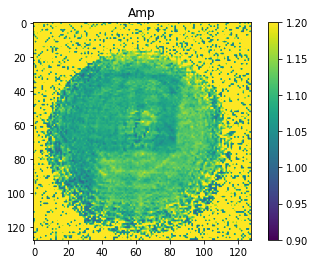

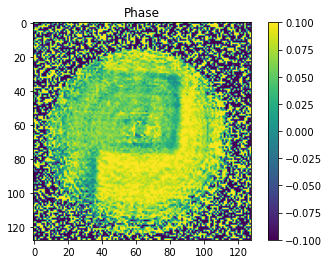

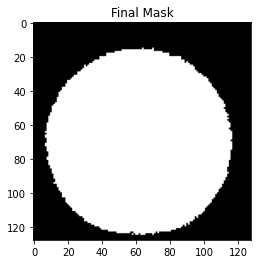

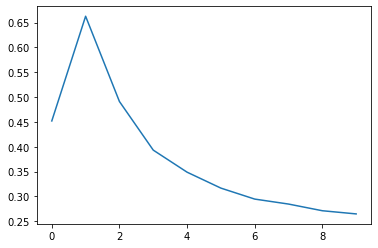

In [90]:
%matplotlib inline
# O = amp_ini*np.exp(1j*pha_ini) # 1+T_contrast
# O = Smask.copy()
O = obj_real.copy()  # initial guess
# mask = combined_mask.copy()
# mask = np.zeros_like(Smask, dtype=bool)
mask = Pmask.copy()
# mask = Smask.copy()
bkg_value = 1.2 * np.exp(1j*(-0.012))
probe_known = probe_defocus.copy()
O_sum = []
# bkg_value = 1
mse = []
for i in range(10):
    esw = np.fft.fftshift(np.fft.fftn(O * probe_known)) / np.sqrt(np.prod(O.shape))
    # esw = fresnel_forward_1fft(O * probe_defocus, 12, 2.05, 75e-6)
    # esw = propagate(O * probe_defocus, 12, 2.05e6, 30e-3, 30e-3)
    
    esw_prime = mags_real*np.exp(1j*np.angle(esw))
    
    esw_back = np.fft.ifftn(np.fft.ifftshift(esw_prime)) * np.sqrt(np.prod(O.shape))
    # esw_back = fresnel_forward_1fft(esw_prime, 12, -2.05, 75e-6)
    # esw_back = propagate(esw_prime, 12, -2.05e6, 30e-3, 30e-3)
    
    
    O_prime = esw_back * np.conj(probe_known) / (np.abs(probe_known)**2 + 1e-6)

    
    O_prime = threshold_object(O_prime, amp_min=1.00, amp_max=1.25, pha_min=-0.1, pha_max=0.1)
    
    T_contrast = O - bkg_value
    T_contrast_prime = O_prime - bkg_value
    if i < 1:
        T_contrast = HIO_T_ERoutside(T_contrast, T_contrast_prime, mask, beta=2)
    else:
        T_contrast = _HIOupdate_contrast2(T_contrast, T_contrast_prime, mask, beta=10) # beta 0.5...
    O = T_contrast + bkg_value
    
    O = threshold_object(O, amp_min=1.00, amp_max=1.25, pha_min=-0.1, pha_max=0.1)
    if i>80:
        O_sum.append(O)
    
    # O = er_update(O_prime, mask)
    mse.append(np.mean((np.abs(fftc(O*probe_defocus)) - mags_real)**2))
    # mse.append(np.mean((np.abs(np.fft.fftshift(np.fft.fftn(O*probe_defocus)))/np.prod(O.shape) - mags_sim)**2))
    
    if i % 10 == 0:
        bkg_value = np.mean(O[~mask])

 

plt.figure()
plt.imshow(np.abs(O), vmin=0.9, vmax=1.2)
plt.title('Amp')
# plt.imshow(np.abs(real_space_guess))
plt.colorbar()

plt.figure()
plt.imshow(np.angle(O), vmin=-0.1, vmax=0.1)
plt.title('Phase')
# plt.imshow(np.angle(new_real_space))
plt.colorbar()


plt.figure()
plt.imshow(mask, cmap='gray')
plt.title('Final Mask')


plt.figure()
plt.plot(mse)
# plt.plot(mse)

# plt.figure()
# plt.imshow(np.mean(np.angle(O_sum), axis=0), vmin=-0.1, vmax=0.1)

plt.show()


In [68]:
eps = 1e-6
beta = 0.9  # DM beta typically ~0.7–1.0

# Use your current definitions
O = obj_real.copy()
mask = Pmask.copy()
probe_known = probe_defocus.copy()

bkg_value = 1.2 * np.exp(1j*(-0.012))
mse = []

norm = np.sqrt(np.prod(O.shape))

def P_M(O_in):
    """Modulus projection (data constraint) mapped back to object using known probe."""
    esw = np.fft.fftshift(np.fft.fftn(O_in * probe_known)) / norm
    esw_prime = mags_real * np.exp(1j * np.angle(esw))
    esw_back = np.fft.ifftn(np.fft.ifftshift(esw_prime)) * norm
    O_out = esw_back * np.conj(probe_known) / (np.abs(probe_known)**2 + eps)
    return O_out

def P_S(O_in, bkg):
    """Support/object projection: outside -> background, inside -> thresholded object."""
    O_out = O_in.copy()

    # enforce outside-support/background
    O_out[~mask] = bkg

    # enforce inside-support constraints (your thresholds)
    O_out[mask] = threshold_object(
        O_out[mask],
        amp_min=1.00, amp_max=1.25,
        pha_min=-0.1, pha_max=0.1
    )
    return O_out

for i in range(20):
    # Projections
    PM_O = P_M(O)
    PS_O = P_S(O, bkg_value)

    # Difference-map auxiliary maps
    fS = (1 + 1/beta) * PS_O - (1/beta) * O
    fM = (1 + 1/beta) * PM_O - (1/beta) * O

    # DM update
    PM_fS = P_M(fS)
    PS_fM = P_S(fM, bkg_value)

    O = O + beta * (PM_fS - PS_fM)

    # (Optional) enforce mild object constraint again (sometimes helps keep things bounded)
    O = P_S(O, bkg_value)

    # Update background periodically (use current estimate outside support)
    if i % 10 == 0:
        bkg_value = np.mean(O[~mask])

    # Error metric (use the SAME normalization convention)
    esw_chk = np.fft.fftshift(np.fft.fftn(O * probe_known)) / norm
    mse.append(np.mean((np.abs(esw_chk) - mags_real)**2))

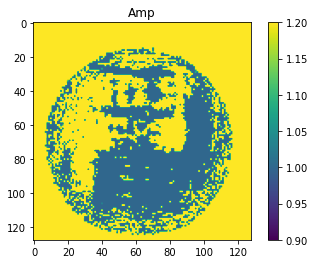

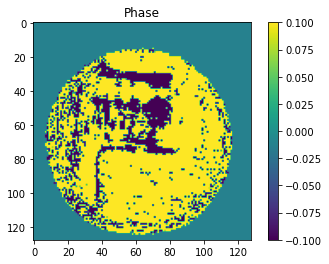

In [69]:
# %matplotlib qt
plt.figure()
plt.imshow(np.abs(O), vmin=0.9, vmax=1.2)
plt.title('Amp')
# plt.imshow(np.abs(real_space_guess))
plt.colorbar()

plt.figure()
plt.imshow(np.angle(O), vmin=-0.1, vmax=0.1)
plt.title('Phase')
# plt.imshow(np.angle(new_real_space))
plt.colorbar()
plt.show()
# %matplotlib inline
